In [337]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime, timedelta

In [375]:
# Инициализация данных для обработки
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  73726 non-null  object 
 1   t1_dtime  73726 non-null  object 
 2   t1_open   73726 non-null  float64
 3   t1_high   73726 non-null  float64
 4   t1_low    73726 non-null  float64
 5   t1_close  73726 non-null  float64
 6   t1_ma5    73726 non-null  float64
 7   t1_ma10   73726 non-null  float64
 8   t2_dtime  73726 non-null  object 
 9   t2_open   73726 non-null  float64
 10  t2_high   73726 non-null  float64
 11  t2_low    73726 non-null  float64
 12  t2_close  73726 non-null  float64
 13  t2_ma5    73726 non-null  float64
 14  t2_ma10   73726 non-null  float64
 15  t3_dtime  73726 non-null  object 
 16  t3_open   73726 non-null  float64
 17  t3_high   73726 non-null  float64
 18  t3_low    73726 non-null  float64
 19  t3_close  73726 non-null  float64
 20  t3_ma5    73726 non-null  fl

In [376]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t5_ma10,t5_ma15,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,0.551600,2001-02-06 00:00:00,...,0.549080,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550,0.548550
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,0.550750,2001-02-06 12:00:00,...,0.548550,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629,0.547629
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,0.549833,2001-02-07 00:00:00,...,0.547629,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275,0.546275
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,0.549725,2001-02-07 12:00:00,...,0.546275,0.546275,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178,0.545178
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,0.549080,2001-02-08 00:00:00,...,0.545178,0.545178,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280,0.544280


In [74]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

In [377]:
COMBINATION_LENGTH = 5
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'

CLASS_LABEL_KEY = 'class'
OPEN_KEY_SUFFIX = 'open'
HIGH_KEY_SUFFIX = 'high'
LOW_KEY_SUFFIX = 'low'
CLOSE_KEY_SUFFIX = 'close'
MA5_KEY_SUFFIX = 'ma5'
MA10_KEY_SUFFIX = 'ma10'
MA15_KEY_SUFFIX = 'ma15'
NUMERIC_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX, MA5_KEY_SUFFIX, MA10_KEY_SUFFIX, MA15_KEY_SUFFIX)

DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_SUFFIX = 'dweek'

IS_WHITE_KEY_SUFFIX = 'is_white'
PART_BODY_KEY_SUFFIX = 'part_body'
PART_HEAD_KEY_SUFFIX = 'head_body'
PART_TAIL_KEY_SUFFIX = 'tail_body'
POSITION_MA5_KEY_SUFFIX = 'ma5_position'
POSITION_MA10_KEY_SUFFIX = 'ma10_position'

In [378]:
# Разметка
target_candle_sizes = data[TARGET_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + LOW_KEY_SUFFIX]
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

buy_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
             (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + HIGH_KEY_SUFFIX]) & 
             (target_candle_body_sizes / target_candle_sizes > 0.5))

sell_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
              (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]) & 
              (target_candle_body_sizes / target_candle_sizes > 0.5))

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 0,)
                                #  np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    62140
1    11586
Name: count, dtype: int64

In [379]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

# Визуализация комбинации
def print_combination(combination_data: pd.Series) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    _, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma15'][:-1], color='#FF4040', label ='ma15')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

2682


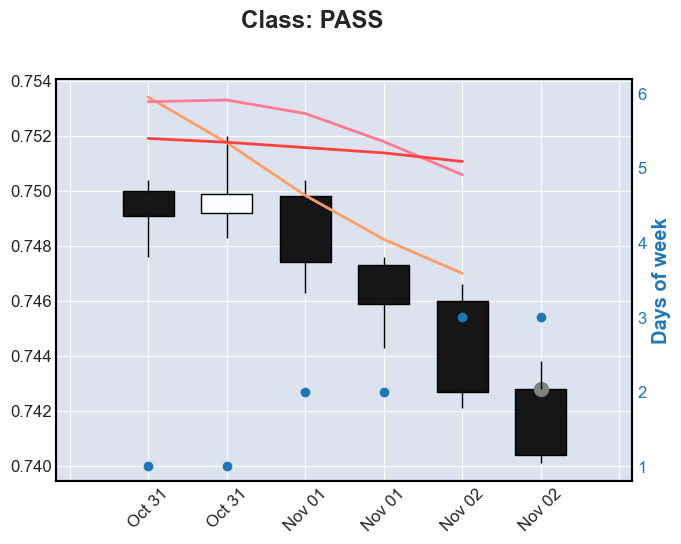

In [381]:
# Печать случайной комбинации
idx = np.random.choice(len(data))
print(idx)
print_combination(data.iloc[idx])

36603


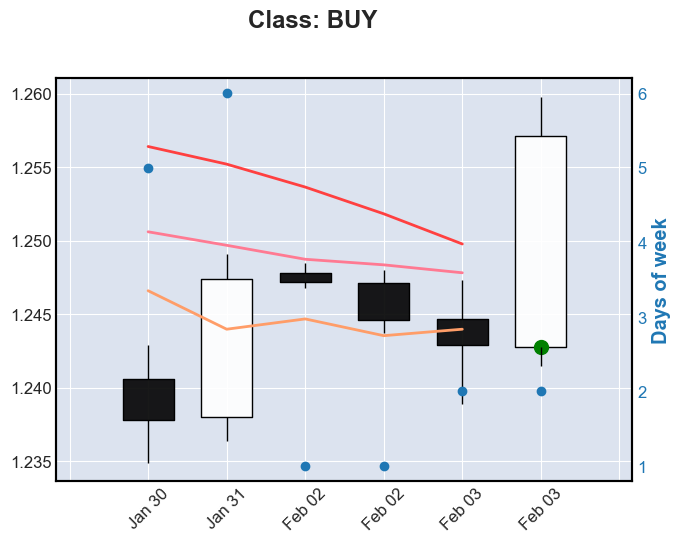

In [387]:
data_true = data[data['class'] == 1]
idx = np.random.choice(data_true.index)
print(idx)
print_combination(data_true.loc[idx])

In [388]:
data.loc[36553]

currency                    EUR
t1_dtime    2003-12-30 00:00:00
t1_open                  1.2489
t1_high                  1.2507
t1_low                   1.2475
t1_close                 1.2482
t1_ma5                  1.24546
t1_ma10                 1.24416
t1_ma15                 1.24242
t2_dtime    2003-12-30 12:00:00
t2_open                  1.2483
t2_high                  1.2505
t2_low                   1.2475
t2_close                 1.2497
t2_ma5                  1.24652
t2_ma10                 1.24518
t2_ma15                1.243227
t3_dtime    2003-12-31 00:00:00
t3_open                  1.2496
t3_high                   1.256
t3_low                   1.2489
t3_close                 1.2545
t3_ma5                  1.24886
t3_ma10                  1.2466
t3_ma15                1.244513
t4_dtime    2003-12-31 12:00:00
t4_open                  1.2546
t4_high                  1.2621
t4_low                   1.2541
t4_close                 1.2601
t4_ma5                   1.2523
t4_ma10 

In [362]:
data_true.loc[36553]

KeyError: 36553

In [389]:
# Предобработка

numeric_columns = [key for key in data.columns if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) and not key.startswith(TARGET_CANDLE_PREFIX)]

# Приведение ценовых показаетелей комбинации в масштаб [0,1]
data_min = data[numeric_columns].min(axis=1)
data_max = data[numeric_columns].max(axis=1)

processed_data = data.copy()
processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')

# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]
for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_SUFFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

# for i in (range(1, COMBINATION_LENGTH + 1)):
#     prefix = f't{i}_'
    
#     data_open = data[prefix + OPEN_KEY_SUFFIX]
#     data_high = data[prefix + HIGH_KEY_SUFFIX]
#     data_low = data[prefix + LOW_KEY_SUFFIX]
#     data_close = data[prefix + CLOSE_KEY_SUFFIX]
#     data_ma5 = data[prefix + MA5_KEY_SUFFIX]
#     data_ma10 = data[prefix + MA10_KEY_SUFFIX]

#     data_size = data_high - data_low

#     # Раскраска свечи
#     processed_data[prefix + IS_WHITE_KEY_SUFFIX] = (data_close > data_open).astype(np.byte)

#     # Дискретизация
#     def part_sampling(p):
#         return np.where(np.isnan(p), 0, np.floor(p * 10)).astype(np.byte)     
    
#     processed_data[prefix + PART_BODY_KEY_SUFFIX] = part_sampling(np.abs(data_close - data_open) / data_size)
#     processed_data[prefix + PART_HEAD_KEY_SUFFIX] = part_sampling((data_high - np.max([data_close, data_open], axis=0)) / data_size)
#     processed_data[prefix + PART_TAIL_KEY_SUFFIX] = part_sampling((np.min([data_close, data_open], axis=0) - data_low) / data_size)

#     # Относительное позиционирование
#     processed_data[prefix + POSITION_MA5_KEY_SUFFIX] = np.where(data_ma5 < data_low, 0,
#                                                                 np.where(data_ma5 < np.min([data_close, data_open], axis=0), 1,
#                                                                          np.where(data_ma5 < np.max([data_close, data_open], axis=0), 2,
#                                                                                   np.where(data_ma5 < data_high, 3, 4))))
    
#     processed_data[prefix + POSITION_MA10_KEY_SUFFIX] = np.where(data_ma10 < data_low, 0,
#                                                             np.where(data_ma10 < np.min([data_close, data_open], axis=0), 1,
#                                                                         np.where(data_ma10 < np.max([data_close, data_open], axis=0), 2,
#                                                                                 np.where(data_ma10 < data_high, 3, 4))))


In [390]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX)]
droped_columns = ['currency'] + dtime_columns + target_candle_columns 
# + numeric_columns

processed_data = processed_data.drop(droped_columns, axis=1)

In [211]:
# Только понедельники
processed_data = processed_data[processed_data['t2_dweek'] == 5]

In [391]:

# pd.set_option('display.max_rows', 100) 
# processed_data.iloc[idx]

processed_data.head()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_close,t5_ma5,t5_ma10,t5_ma15,class,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
0,0.724138,1.0,0.701149,0.827586,0.827586,0.827586,0.827586,0.862069,0.954023,0.413793,...,0.241379,0.537931,0.537931,0.537931,0,0,1,1,2,2
1,0.903614,1.0,0.433735,0.662651,0.765060,0.765060,0.765060,0.650602,0.819277,0.349398,...,0.180723,0.426506,0.500000,0.500000,0,1,1,2,2,3
2,0.855670,1.0,0.597938,0.670103,0.859107,0.859107,0.859107,0.659794,0.948454,0.567010,...,0.061856,0.503093,0.631811,0.631811,0,1,2,2,3,3
3,0.846154,1.0,0.796703,0.928571,0.946429,0.946429,0.946429,0.928571,0.956044,0.653846,...,0.236264,0.639560,0.756868,0.756868,0,2,2,3,3,4
4,0.971264,1.0,0.683908,0.804598,0.952874,0.952874,0.952874,0.758621,0.798851,0.689655,...,0.224138,0.519540,0.728608,0.728608,0,2,3,3,4,4


In [392]:
processed_data.isnull().sum()

t1_open     0
t1_high     0
t1_low      0
t1_close    0
t1_ma5      0
t1_ma10     0
t1_ma15     0
t2_open     0
t2_high     0
t2_low      0
t2_close    0
t2_ma5      0
t2_ma10     0
t2_ma15     0
t3_open     0
t3_high     0
t3_low      0
t3_close    0
t3_ma5      0
t3_ma10     0
t3_ma15     0
t4_open     0
t4_high     0
t4_low      0
t4_close    0
t4_ma5      0
t4_ma10     0
t4_ma15     0
t5_open     0
t5_high     0
t5_low      0
t5_close    0
t5_ma5      0
t5_ma10     0
t5_ma15     0
class       0
t1_dweek    0
t2_dweek    0
t3_dweek    0
t4_dweek    0
t5_dweek    0
dtype: int64

In [402]:
# Моделирование
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split

# Разделение на множества данных
X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    43498
1     8110
Name: count, dtype: int64
Валидационный набор: class
0    9321
1    1738
Name: count, dtype: int64
Тестовый набор: class
0    9321
1    1738
Name: count, dtype: int64


In [401]:
y_test.index

Index([58939, 36551, 18869, 67493, 16423, 19020, 63502, 72499, 40308, 69864,
       ...
       35102, 65418, 71781, 23286, 72673, 72730, 29168, 63130, 47250, 44586],
      dtype='int64', length=11059)

In [372]:
X_test.loc[36553]

t1_open     0.292155
t1_high     0.373309
t1_low      0.229035
t1_close    0.260595
t1_ma5      0.137060
t1_ma10     0.078449
t1_ma15     0.000000
t2_open     0.265104
t2_high     0.364292
t2_low      0.229035
t2_close    0.328224
t2_ma5      0.184851
t2_ma10     0.124436
t2_ma15     0.036369
t3_open     0.323715
t3_high     0.612263
t3_low      0.292155
t3_close    0.544635
t3_ma5      0.290352
t3_ma10     0.188458
t3_ma15     0.094379
t4_open     0.549143
t4_high     0.887286
t4_low      0.526601
t4_close    0.797115
t4_ma5      0.445446
t4_ma10     0.256537
t4_ma15     0.146078
t5_open     0.801623
t5_high     1.000000
t5_low      0.395852
t5_close    0.756537
t5_ma5      0.537421
t5_ma10     0.319657
t5_ma15     0.206192
t1_dweek    1.000000
t2_dweek    1.000000
t3_dweek    2.000000
t4_dweek    2.000000
t5_dweek    3.000000
Name: 36553, dtype: float64

In [323]:
y_test.loc[36553]

np.int64(1)

In [395]:
from catboost import CatBoostClassifier

def fit_classifier(X_train, y_train, **kwargs):
    clf = CatBoostClassifier(
        **kwargs,
        learning_rate=0.08, 
        auto_class_weights='Balanced', 
        leaf_estimation_iterations=3,
        logging_level="Silent"
        )
    clf.fit(X_train, y_train)
    return clf

# Кривая обучения
def train(X_train, y_train, X_val, y_val, **kwargs):
    clf = fit_classifier(X_train=X_train, y_train=y_train, **kwargs)

    y_train_pred = clf.predict(X_train)
    q_train = precision_score(y_true=y_train, y_pred=y_train_pred)

    y_val_pred = clf.predict(X_val)
    q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

    print(f'Args: {kwargs}, Val qual: {q_val}, Val pred {y_val_pred.sum()}')

    return q_train, q_val

In [396]:
# Печать кривой обучения
def print_train_curve(ax1, title, xlabel, complexity, quals_train, quals_val):
    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

Args: {'n_estimators': 600, 'max_depth': 6}, Val qual: 0.3157894736842105, Val pred 171
Args: {'n_estimators': 700, 'max_depth': 6}, Val qual: 0.3136094674556213, Val pred 169
Args: {'n_estimators': 800, 'max_depth': 6}, Val qual: 0.3202614379084967, Val pred 153
Args: {'n_estimators': 900, 'max_depth': 6}, Val qual: 0.302158273381295, Val pred 139
Args: {'n_estimators': 1000, 'max_depth': 6}, Val qual: 0.2867647058823529, Val pred 136
Args: {'n_estimators': 1100, 'max_depth': 6}, Val qual: 0.29365079365079366, Val pred 126
Args: {'n_estimators': 600, 'max_depth': 7}, Val qual: 0.2605633802816901, Val pred 142
Args: {'n_estimators': 700, 'max_depth': 7}, Val qual: 0.28225806451612906, Val pred 124
Args: {'n_estimators': 800, 'max_depth': 7}, Val qual: 0.25217391304347825, Val pred 115
Args: {'n_estimators': 900, 'max_depth': 7}, Val qual: 0.24299065420560748, Val pred 107
Args: {'n_estimators': 1000, 'max_depth': 7}, Val qual: 0.24742268041237114, Val pred 97
Args: {'n_estimators': 110

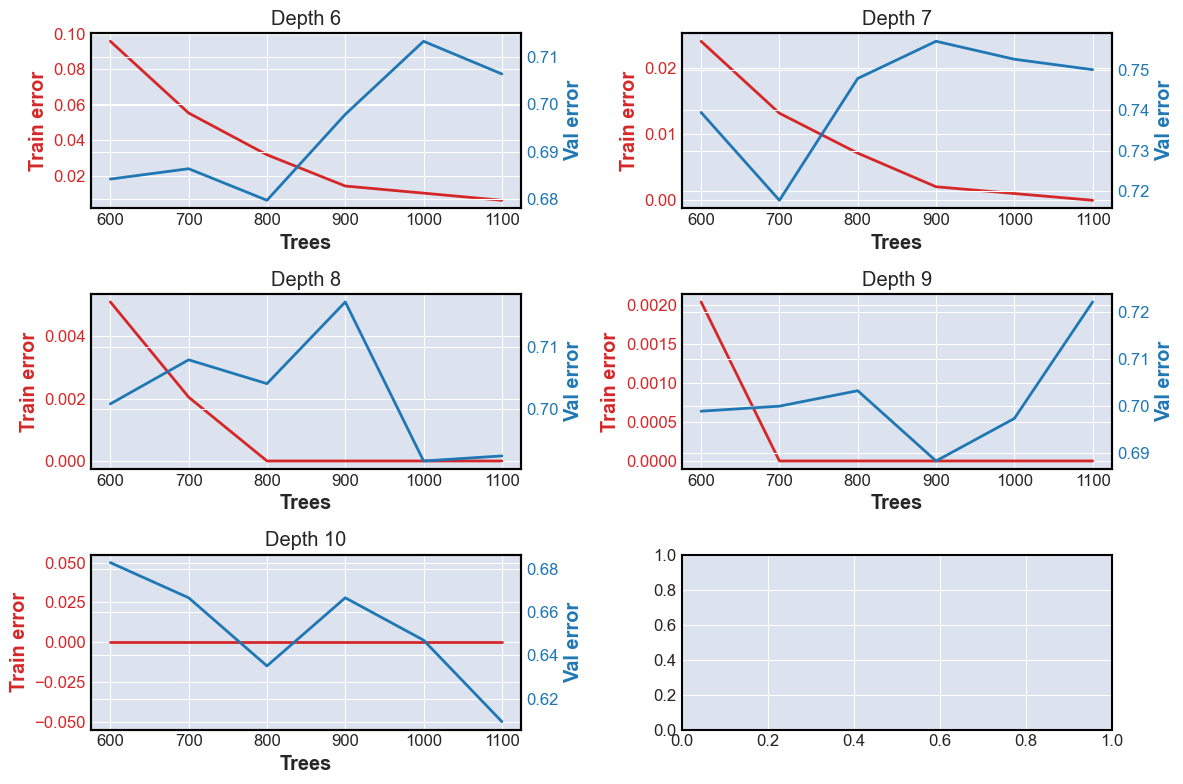

In [214]:
axes_columns_num = 2
# depth = range(8, 14)
# trees = range(800, 1500, 100)
depth = range(6, 11)
trees = range(600, 1200, 100)

fig, axes = plt.subplots(ncols=axes_columns_num, nrows=math.ceil(len(depth)/axes_columns_num), figsize=(12, 8))

for i, d in enumerate(depth):
    quals_train = []
    quals_val = []

    for t in trees:
        q_train, q_val = train(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, n_estimators=t, max_depth=d)

        quals_train.append(1 - q_train)
        quals_val.append(1 - q_val)

    print_train_curve(axes[i//axes_columns_num][i%axes_columns_num], f'Depth {d}', 'Trees', trees, quals_train, quals_val)

fig.tight_layout()
plt.show()

In [403]:
clf = fit_classifier(X_train=X_train, y_train=y_train, n_estimators=1000, max_depth=10)

y_val_pred = clf.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

print(q_val)

0.2407766990291262


In [404]:
y_test_pred = clf.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred)

print(q_test)

0.22254901960784312


In [399]:
y_test_pred[1]

np.int64(1)

In [361]:
X_test.iloc[1]

t1_open     0.292155
t1_high     0.373309
t1_low      0.229035
t1_close    0.260595
t1_ma5      0.137060
t1_ma10     0.078449
t1_ma15     0.000000
t2_open     0.265104
t2_high     0.364292
t2_low      0.229035
t2_close    0.328224
t2_ma5      0.184851
t2_ma10     0.124436
t2_ma15     0.036369
t3_open     0.323715
t3_high     0.612263
t3_low      0.292155
t3_close    0.544635
t3_ma5      0.290352
t3_ma10     0.188458
t3_ma15     0.094379
t4_open     0.549143
t4_high     0.887286
t4_low      0.526601
t4_close    0.797115
t4_ma5      0.445446
t4_ma10     0.256537
t4_ma15     0.146078
t5_open     0.801623
t5_high     1.000000
t5_low      0.395852
t5_close    0.756537
t5_ma5      0.537421
t5_ma10     0.319657
t5_ma15     0.206192
t1_dweek    1.000000
t2_dweek    1.000000
t3_dweek    2.000000
t4_dweek    2.000000
t5_dweek    3.000000
Name: 36553, dtype: float64

In [281]:
y_test

58940    0
36553    1
18871    1
67494    0
16423    0
        ..
72729    0
29167    0
63131    0
47252    1
44586    0
Name: class, Length: 11059, dtype: int64

In [400]:
data_test_pred_class = pd.concat([pd.DataFrame(y_test_pred, columns=['pred_class'], index=X_test.index), y_test], axis=1)
data_test_pred_class

,pred_class,class
58939,0,0
36551,1,1
18869,0,1
67493,1,0
16423,1,0
...,...,...
72730,0,0
29168,0,0
63130,0,0
47250,0,1


In [48]:
data_test = pd.concat([data, data_test_pred_class], axis=1)
data_test = data_test[(data_test['class'] + data_test['pred_class']) > 0]
data_test

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15,class,pred_class
92,AUD,2001-04-07 00:00:00,0.4912,0.4987,0.4911,0.4982,0.49214,0.48856,0.488600,2001-04-10 00:00:00,...,2001-04-12 00:00:00,0.5007,0.5045,0.5006,0.5031,0.49768,0.49491,0.491600,1,1.0
123,AUD,2001-04-28 00:00:00,0.5113,0.5119,0.5072,0.5091,0.50924,0.50710,0.509073,2001-04-30 00:00:00,...,2001-05-02 00:00:00,0.5146,0.5190,0.5144,0.5176,0.51200,0.51062,0.508733,1,1.0
139,AUD,2001-05-09 00:00:00,0.5200,0.5205,0.5144,0.5170,0.51858,0.51913,0.517487,2001-05-09 12:00:00,...,2001-05-11 12:00:00,0.5231,0.5250,0.5215,0.5232,0.52332,0.52095,0.520527,1,1.0
286,AUD,2001-08-21 00:00:00,0.5322,0.5323,0.5322,0.5323,0.53230,0.52800,0.523773,2001-08-21 12:00:00,...,2001-08-23 12:00:00,0.5352,0.5355,0.5326,0.5330,0.53492,0.53361,0.530307,1,1.0
341,AUD,2001-09-27 00:00:00,0.4958,0.4963,0.4885,0.4887,0.49266,0.49027,0.491400,2001-09-27 12:00:00,...,2001-10-01 00:00:00,0.4915,0.4938,0.4915,0.4930,0.49050,0.49158,0.490347,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73521,NZD,2021-01-22 12:00:00,0.7210,0.7225,0.7173,0.7179,0.71840,0.71505,0.716147,2021-01-23 00:00:00,...,2021-01-26 12:00:00,0.7198,0.7217,0.7164,0.7216,0.71964,0.71902,0.716580,1,1.0
73541,NZD,2021-02-04 12:00:00,0.7221,0.7225,0.7168,0.7168,0.71878,0.71806,0.717880,2021-02-05 00:00:00,...,2021-02-08 12:00:00,0.7210,0.7211,0.7177,0.7179,0.71780,0.71829,0.717973,1,1.0
73570,NZD,2021-02-23 12:00:00,0.7326,0.7333,0.7303,0.7326,0.73134,0.72637,0.725060,2021-02-24 00:00:00,...,2021-02-26 00:00:00,0.7445,0.7457,0.7357,0.7359,0.73932,0.73533,0.730687,1,1.0
73627,NZD,2021-03-31 12:00:00,0.6991,0.7001,0.6961,0.6996,0.69948,0.69871,0.699880,2021-04-01 00:00:00,...,2021-04-03 00:00:00,0.7033,0.7047,0.7011,0.7030,0.70094,0.70021,0.699453,1,1.0


In [279]:
data_true = data[data['class'] == 1]
data_true

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t5_ma15,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15,class
12,AUD,2001-02-14 00:00:00,0.5379,0.5386,0.5314,0.5321,0.53620,0.54017,0.542400,2001-02-14 12:00:00,...,0.537013,2001-02-16 12:00:00,0.5244,0.5305,0.5243,0.5286,0.52682,0.53151,0.535720,1
19,AUD,2001-02-19 00:00:00,0.5288,0.5296,0.5278,0.5285,0.52676,0.52995,0.533127,2001-02-19 12:00:00,...,0.529480,2001-02-21 12:00:00,0.5227,0.5273,0.5223,0.5254,0.52638,0.52657,0.528760,1
24,AUD,2001-02-21 12:00:00,0.5227,0.5273,0.5223,0.5254,0.52638,0.52657,0.528760,2001-02-22 00:00:00,...,0.525640,2001-02-24 00:00:00,0.5223,0.5267,0.5208,0.5267,0.52380,0.52509,0.525647,1
27,AUD,2001-02-23 00:00:00,0.5212,0.5260,0.5205,0.5238,0.52366,0.52588,0.526193,2001-02-23 12:00:00,...,0.525633,2001-02-27 12:00:00,0.5217,0.5258,0.5215,0.5250,0.52442,0.52404,0.525393,1
31,AUD,2001-02-27 00:00:00,0.5212,0.5234,0.5205,0.5215,0.52418,0.52400,0.525633,2001-02-27 12:00:00,...,0.524807,2001-03-01 12:00:00,0.5261,0.5290,0.5255,0.5280,0.52614,0.52516,0.524713,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73707,NZD,2021-05-21 00:00:00,0.7182,0.7215,0.7180,0.7194,0.71908,0.72110,0.720340,2021-05-21 12:00:00,...,0.720393,2021-05-25 00:00:00,0.7177,0.7220,0.7175,0.7213,0.71876,0.71892,0.720320,1
73708,NZD,2021-05-21 12:00:00,0.7195,0.7222,0.7171,0.7207,0.71852,0.72068,0.720180,2021-05-22 00:00:00,...,0.720320,2021-05-25 12:00:00,0.7213,0.7244,0.7207,0.7240,0.71942,0.71897,0.720260,1
73710,NZD,2021-05-24 00:00:00,0.7172,0.7182,0.7159,0.7169,0.71846,0.71973,0.720407,2021-05-24 12:00:00,...,0.720127,2021-05-26 12:00:00,0.7223,0.7315,0.7221,0.7303,0.72314,0.72080,0.720867,1
73717,NZD,2021-05-27 12:00:00,0.7276,0.7310,0.7263,0.7300,0.72678,0.72277,0.721540,2021-05-28 00:00:00,...,0.723073,2021-05-31 12:00:00,0.7241,0.7262,0.7229,0.7260,0.72500,0.72589,0.723513,1


In [311]:
data.loc[49021]

currency                    GBP
t1_dtime    2006-05-22 00:00:00
t1_open                  1.8764
t1_high                  1.8783
t1_low                   1.8758
t1_close                 1.8762
t1_ma5                  1.88202
t1_ma10                 1.88329
t1_ma15                1.885907
t2_dtime    2006-05-22 12:00:00
t2_open                   1.876
t2_high                  1.8777
t2_low                   1.8631
t2_close                 1.8751
t2_ma5                  1.88016
t2_ma10                 1.88303
t2_ma15                 1.88528
t3_dtime    2006-05-23 00:00:00
t3_open                  1.8753
t3_high                  1.8886
t3_low                   1.8733
t3_close                 1.8847
t3_ma5                   1.8782
t3_ma10                  1.8834
t3_ma15                 1.88462
t4_dtime    2006-05-23 12:00:00
t4_open                  1.8848
t4_high                  1.8883
t4_low                   1.8793
t4_close                 1.8843
t4_ma5                  1.87996
t4_ma10 

In [ ]:
data_test.iloc[49021]

KeyError: 49021

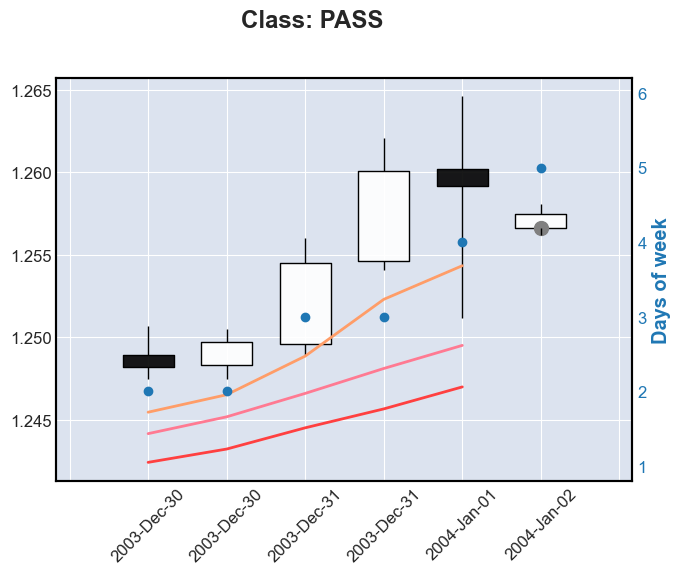

In [290]:
print_combination(data.iloc[36553])

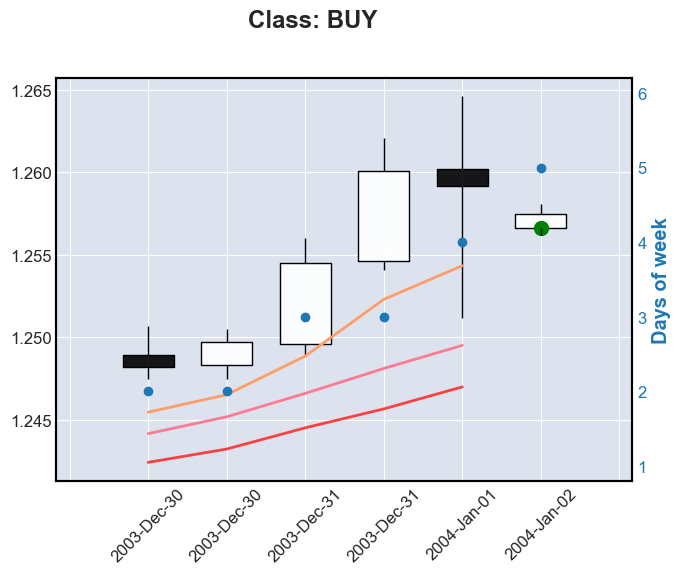

In [347]:
print_combination(data_test.loc[36553])

In [340]:
print_combination(X_test.iloc[1])

KeyError: "None of [Index(['t6_open', 't6_high', 't6_low', 't6_close', 't6_ma5', 't6_ma10',\n       't6_ma15'],\n      dtype='object')] are in the [index]"

In [345]:
pd.Timestamp(datetime.now() + timedelta(days=1))

Timestamp('2026-04-14 15:27:31.280293')

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(X_val)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
# X_val_scaled = scaler.transform(X_val)

X_val_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_low,t5_close,t5_ma5,t5_ma10,t5_ma15,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
count,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,...,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000
mean,0.496813,0.674511,0.312391,0.501470,0.498141,0.496378,0.494254,0.501126,0.685967,0.310626,...,0.322907,0.508553,0.487766,0.530283,0.500867,0.459047,0.452844,0.450276,0.450475,0.452139
std,0.267743,0.257802,0.253510,0.234610,0.249147,0.314227,0.390977,0.234562,0.229218,0.225207,...,0.283600,0.301810,0.171069,0.163454,0.232969,0.322761,0.320629,0.321706,0.318517,0.318567
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.278938,0.468446,0.066013,0.311617,0.301504,0.207551,0.064937,0.312913,0.509785,0.116524,...,0.022198,0.226667,0.367241,0.410784,0.287282,0.200000,0.200000,0.200000,0.200000,0.200000
50%,0.493573,0.690880,0.291995,0.498626,0.496081,0.493651,0.488095,0.498891,0.704314,0.293461,...,0.276674,0.512591,0.489495,0.529495,0.496499,0.400000,0.400000,0.400000,0.400000,0.400000
75%,0.717845,0.919895,0.511193,0.686275,0.692157,0.786283,0.918948,0.687573,0.884354,0.483009,...,0.573555,0.794144,0.609645,0.649320,0.716278,0.800000,0.800000,0.800000,0.800000,0.800000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
y_val_pred.sum()

np.int64(1892)

In [33]:
y_val.sum()

np.int64(1738)

In [54]:
103.45 - 90.9

12.549999999999997

In [37]:
(y_val * y_val_pred.squeeze()).count()

np.int64(11059)

In [29]:
y_val_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(11059,))

In [61]:
y_val

3084     0
2220     0
66616    0
48177    0
53687    0
        ..
33032    0
22680    0
29680    1
21299    0
18407    0
Name: class, Length: 11059, dtype: int64

In [19]:
len(y_val)

11059

In [67]:
X_val

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.400000,0.623529,0.498824,0.309412,0.611765,0.929412,0.505882,0.552941,...,3,4,4,5,0,1,0,0,1,0
2220,0.000000,0.335570,0.000000,0.290828,0.519016,1.000000,0.302013,0.458613,0.100671,0.391499,...,0,0,1,1,2,1,1,1,1,1
66616,0.573034,0.685393,0.235955,0.505618,0.370787,0.379775,0.516854,1.000000,0.393258,0.797753,...,1,1,2,2,3,0,1,0,0,1
48177,0.092820,0.364273,0.000000,0.357268,0.143608,0.069527,0.355517,0.462347,0.327496,0.394046,...,1,2,2,3,3,1,1,1,1,1
53687,0.773131,0.887199,0.481622,0.570342,0.712294,1.000000,0.583016,0.633714,0.304183,0.468948,...,0,1,1,2,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.808219,0.607306,0.698630,0.490411,0.000000,0.716895,0.936073,0.607306,0.908676,...,4,5,0,0,1,0,1,1,1,0
22680,0.824818,1.000000,0.700730,0.744526,0.702190,0.559854,0.729927,0.795620,0.445255,0.510949,...,2,2,3,3,4,0,0,0,1,1
29680,0.484848,0.787879,0.128788,0.765152,0.601515,0.848485,0.765152,1.000000,0.416667,0.446970,...,3,4,4,5,0,1,0,1,0,0
21299,0.523256,0.843023,0.517442,0.598837,0.641860,0.536047,0.604651,0.674419,0.505814,0.656977,...,1,1,2,2,3,1,1,0,0,0


In [68]:
X_val_scaled

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white
3084,0.423529,1.000000,0.407143,0.622811,0.498824,0.309412,0.611765,0.924610,0.515080,0.552941,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2220,0.000000,0.312855,0.000000,0.289474,0.519016,1.000000,0.302013,0.421784,0.102502,0.391499,...,0.0,0.0,0.2,0.2,0.4,1.0,1.0,1.0,1.0,1.0
66616,0.573034,0.674637,0.240169,0.504675,0.370787,0.379775,0.516854,1.000000,0.400409,0.797753,...,0.2,0.2,0.4,0.4,0.6,0.0,1.0,0.0,0.0,1.0
48177,0.092820,0.342539,0.000000,0.356041,0.143608,0.069527,0.355517,0.425772,0.333450,0.394046,...,0.2,0.4,0.4,0.6,0.6,1.0,1.0,1.0,1.0,1.0
53687,0.773131,0.883343,0.490223,0.569522,0.712294,1.000000,0.583016,0.608796,0.309713,0.468948,...,0.0,0.2,0.2,0.4,0.4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33032,0.698630,0.801663,0.618151,0.698055,0.490411,0.000000,0.716895,0.931724,0.618348,0.908676,...,0.8,1.0,0.0,0.0,0.2,0.0,1.0,1.0,1.0,0.0
22680,0.824818,1.000000,0.713243,0.744038,0.702190,0.559854,0.729927,0.781717,0.453351,0.510949,...,0.4,0.4,0.6,0.6,0.8,0.0,0.0,0.0,1.0,1.0
29680,0.484848,0.780627,0.131088,0.764703,0.601515,0.848485,0.765152,1.000000,0.424242,0.446970,...,0.6,0.8,0.8,1.0,0.0,1.0,0.0,1.0,0.0,0.0
21299,0.523256,0.837657,0.526682,0.598072,0.641860,0.536047,0.604651,0.652270,0.515011,0.656977,...,0.2,0.2,0.4,0.4,0.6,1.0,1.0,0.0,0.0,0.0


In [34]:
X_val_scaled_with_pred = X_val_scaled.copy()
X_val_scaled_with_pred = pd.concat([X_val_scaled_with_pred, y_val], axis=1)
X_val_scaled_with_pred['class_pred'] = y_val_pred

In [35]:
y_val_pred.sum()

np.int64(1892)

In [36]:
X_val_scaled_is_class_true = X_val_scaled_with_pred[X_val_scaled_with_pred['class'] == 1]
y_val_scaled_pred_class = X_val_scaled_is_class_true['class_pred']
X_val_scaled_is_class_true = X_val_scaled_is_class_true.drop(['class', 'class_pred'], axis=1)

In [37]:
X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_low,t5_close,t5_ma5,t5_ma10,t5_ma15,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
70001,0.421429,0.606716,0.142083,0.235714,0.661429,0.662143,0.521429,0.228571,0.397813,0.000000,...,0.526270,0.528571,0.436726,0.667530,0.639470,0.6,0.6,0.8,0.8,1.0
36627,0.213759,0.197593,0.063021,0.072482,0.423833,0.249386,0.000000,0.078624,0.296746,0.023766,...,0.574112,0.877150,0.448895,0.542849,0.313975,0.0,0.0,0.2,0.2,0.4
54614,0.521127,0.866950,0.394440,0.785211,0.475352,0.138380,0.000000,0.764085,0.791104,0.752881,...,0.744931,0.771127,0.776376,0.573725,0.240120,1.0,0.0,0.0,0.2,0.2
68864,0.201681,0.228856,0.000000,0.067227,0.196639,0.125210,0.070028,0.075630,0.256560,0.051337,...,0.831418,0.890756,0.456758,0.375220,0.201538,0.6,0.8,0.8,1.0,0.0
9115,0.124138,0.322457,0.079422,0.193103,0.067586,0.022069,0.063908,0.179310,0.296552,0.000000,...,0.725889,0.724138,0.435928,0.218796,0.128068,0.4,0.4,0.6,0.6,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23189,0.331950,0.543073,0.112946,0.431535,0.585062,0.994072,0.994072,0.435685,0.542214,0.092946,...,0.681312,0.917012,0.547832,0.805136,0.879105,0.6,0.6,0.8,0.8,1.0
41956,0.438959,0.505748,0.426664,0.474865,0.501795,0.206463,0.000000,0.474865,0.584234,0.369251,...,0.646263,0.968582,0.716729,0.590211,0.297468,0.0,0.0,0.2,0.2,0.4
63805,0.088889,0.364234,0.000000,0.355556,0.331111,0.505556,0.533333,0.377778,0.560544,0.192323,...,0.725083,0.977778,0.655300,0.514733,0.572042,0.4,0.4,0.6,0.6,0.8
48945,0.299728,0.261635,0.000000,0.106267,0.329700,0.382016,0.413987,0.103542,0.432798,0.047164,...,0.742800,0.722071,0.512336,0.482762,0.462576,0.0,0.2,0.2,0.4,0.4


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\mazurenko\.conda\envs\otus-ml\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\mazurenko\.conda\envs\otus-ml\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\mazurenko\.conda\envs\otus-ml\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8d in position 4: invalid start byte


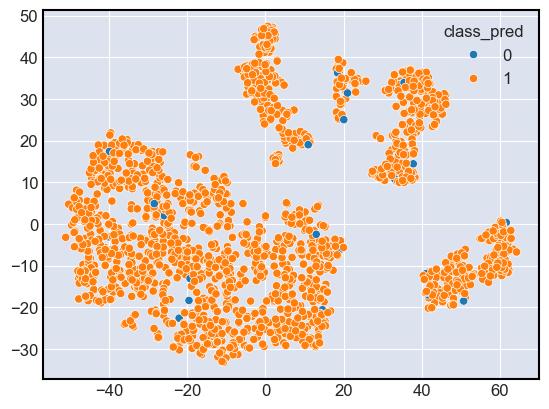

In [38]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_val_scaled_pred_class)

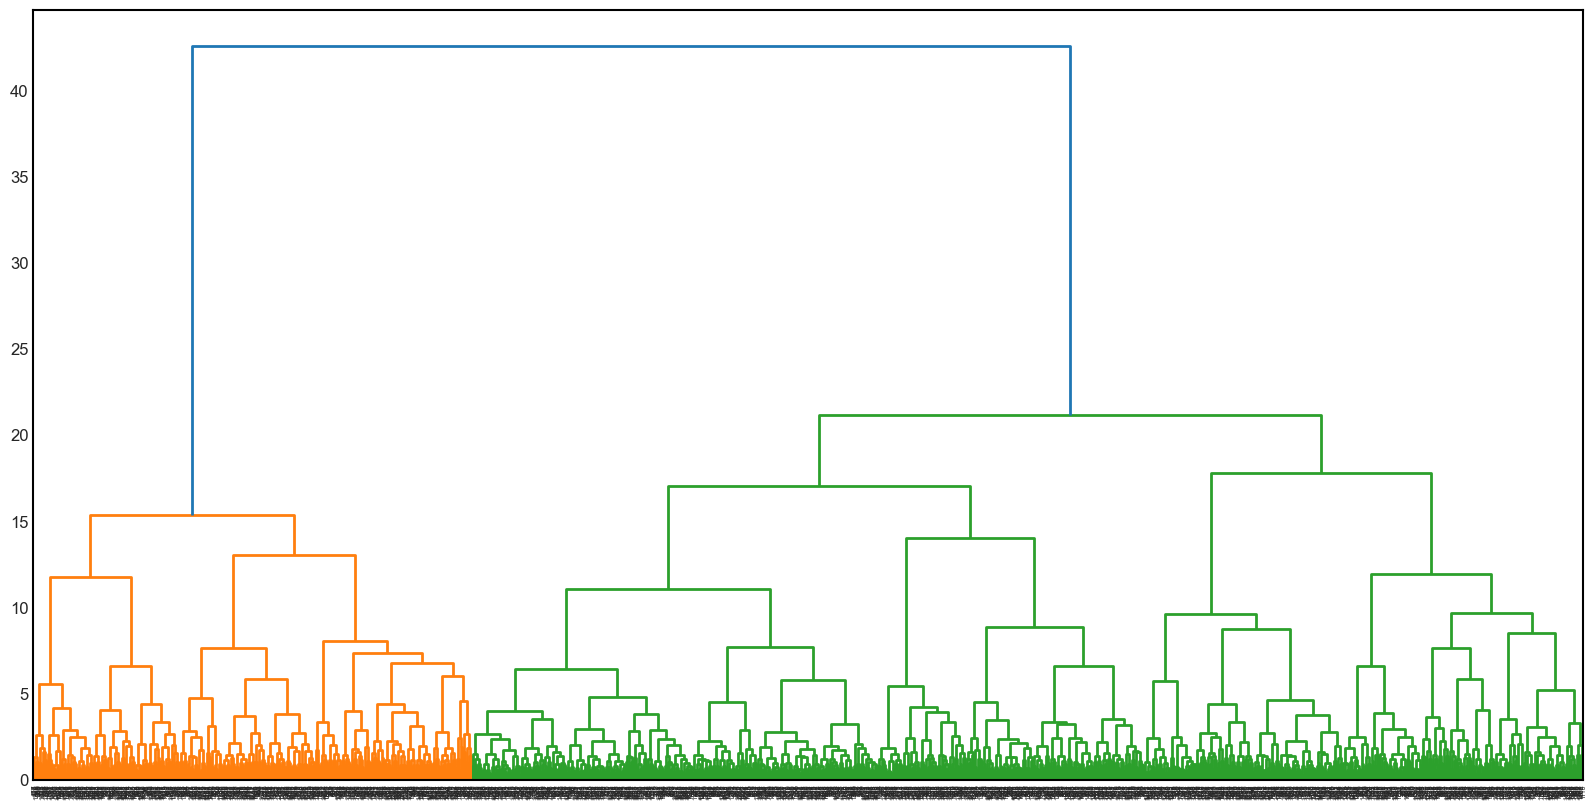

In [39]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))
linkage_ = linkage(X_val_scaled_is_class_true, method='ward')
dendrogram_ = dendrogram(linkage_)


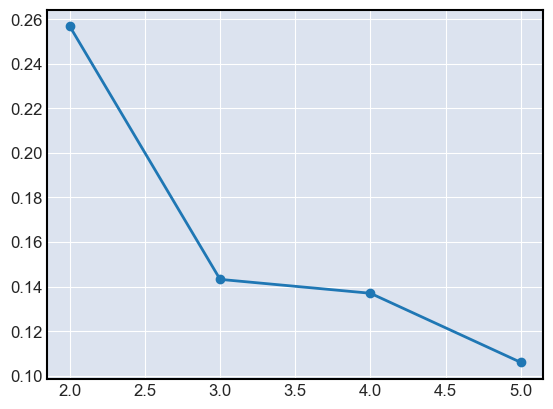

In [41]:
silhouette = []
clasters = range(2,6)
for i in clasters:
    agg = AgglomerativeClustering(n_clusters=i).fit(X_val_scaled_is_class_true)
    labels = agg.labels_
    score = silhouette_score(X_val_scaled_is_class_true, labels)
    silhouette.append(score)

plt.plot(clasters, silhouette, marker='o');

In [42]:
agg = AgglomerativeClustering(n_clusters=4).fit(X_val_scaled_is_class_true)
labels = agg.labels_

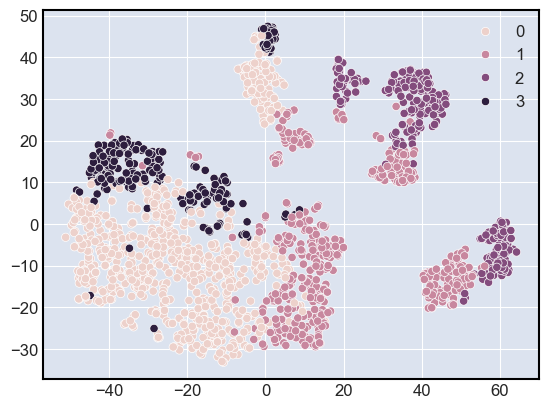

In [43]:
tsne = TSNE(n_components=2, random_state=10)

train_tsne = tsne.fit_transform(X_val_scaled_is_class_true)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=labels)

In [108]:
X_val_scaled_is_class_true['labels'] = labels
X_val_scaled_is_class_true['class_pred'] = y_val_scaled_pred_class

X_val_scaled_is_class_true

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t3_dweek,t4_dweek,t5_dweek,t1_is_white,t2_is_white,t3_is_white,t4_is_white,t5_is_white,labels,class_pred
69999,0.928571,1.000000,0.575574,0.582538,0.722619,0.589881,0.589286,0.567703,0.187879,0.339286,...,0.6,0.6,0.8,0.0,0.0,0.0,1.0,0.0,0,0
36625,0.562500,0.676816,0.445312,0.561665,0.413636,0.170455,0.568182,1.000000,0.000000,0.142045,...,0.0,0.0,0.2,0.0,0.0,0.0,1.0,1.0,10,0
54612,0.285193,0.800102,0.279150,0.714993,0.287381,0.000000,0.722830,0.711765,0.550308,0.628009,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,7,0
68862,0.760563,0.810642,0.200704,0.421433,0.791549,0.402817,0.422535,0.638977,0.000000,0.647887,...,0.6,0.8,0.8,0.0,1.0,0.0,1.0,1.0,9,0
9113,0.103896,0.503053,0.000000,0.492540,0.262338,0.336364,0.519481,0.556145,0.185124,0.519481,...,0.4,0.4,0.6,1.0,0.0,1.0,1.0,0.0,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23181,0.627907,0.651262,0.248547,0.277694,0.655814,0.862791,0.302326,0.813716,0.000000,0.720930,...,0.4,0.6,0.6,0.0,1.0,1.0,0.0,1.0,3,0
41954,0.762675,0.921906,0.682963,0.848687,0.298813,0.000000,0.848975,1.000000,0.501952,0.638619,...,0.0,0.0,0.2,1.0,0.0,1.0,1.0,1.0,7,0
63804,0.576471,1.000000,0.000000,0.163112,0.416471,0.622353,0.164706,0.472269,0.071872,0.447059,...,0.4,0.6,0.6,0.0,1.0,1.0,1.0,1.0,5,0
48943,0.493274,0.712468,0.392537,0.559699,0.646637,0.761435,0.547085,0.554590,0.493110,0.488789,...,0.0,0.2,0.2,1.0,0.0,0.0,1.0,1.0,10,0


In [109]:
X_val_scaled_is_class_true[['class_pred','labels']].groupby('labels').agg(['count', 'sum', 'mean'])

class_pred              
            count sum      mean
labels                         
0             163  17  0.104294
1             144  22  0.152778
2             208  32  0.153846
3             153  32  0.209150
4             129  26  0.201550
5             125  18  0.144000
6             155  26  0.167742
7             126  22  0.174603
8              96  18  0.187500
9              92  18  0.195652
10            117  21  0.179487
11             83  17  0.204819
12             85  12  0.141176
13             62  13  0.209677

In [112]:
X_val_scaled_is_class_true['class_pred'].agg(['count', 'sum', 'mean'])

count    1738.00000
sum       294.00000
mean        0.16916
Name: class_pred, dtype: float64